# Graduation Lab (Week 6)

## Instructions:

Let's build a kNN model using the college completion data from last week. 
The data is messy and you have a degrees of freedom problem, as in, we have too many features.  

You've done most of the hard work already, so you should be ready to move forward with building your model. 

1. Use the question/target variable you submitted from last week and build a model to answer the question you created for this dataset. 

2. Build and optimize a kNN model to predict your target variable. Meaning use the tune set to select the correct k value. 

3. Experiment with the threshold function, what happens at higher and lower thresholds. Document what you see in comments. 

4. Evaluate the results using the confusion matrix (at the default threshold). Then talk through your question, summarize what concerns or positive elements do you have about the model? 

Bonus: Adjust the function that selects k to output on Specificity instead of Accuracy

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score


In [2]:
college = pd.read_csv('/workspaces/DS-3021/data/cc_institution_details.csv')
college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


### 1. Use the question/target variable you submitted from last week and build a model to answer the question you created for this dataset. 

Question: Can we predict the type of college based on number of awards per 100 students, hbcu status, cohort size, percentage of full time students, and the number of colleges in the same state and sector?

In [3]:
#Target: control
#independents: awards_per_value, hbcu, state_sector_ct, cohort_size, ft_pct

columns_used = ['control','hbcu', 'cohort_size', 'awards_per_value', 'state_sector_ct', 'ft_pct']
college_filtered = college[columns_used]

In [4]:
def college_cleaning(dataset):
    global Train, Test, Tune
    #clean up hbcu column
    dataset['hbcu'].fillna('N', inplace=True)
    dataset['hbcu'].replace('X', 'Y', inplace=True)
    dataset.dropna(inplace=True)
    #simplify control column
    dataset['control'].replace('Private not-for-profit', 'Private', inplace=True)
    dataset['control'].replace('Private for-profit', 'Private', inplace=True)
    # Convert specified columns to 'category' dtype individually
    Column_list = ['control', 'hbcu']
    for column in Column_list:
        dataset[column] = dataset[column].astype('category')
    #drop outliers
    dataset = dataset[dataset['cohort_size'] <= 8100]
    dataset = dataset[dataset['awards_per_value'] <= 77]
    #standardize the data!
    numeric_columns = ['cohort_size', 'awards_per_value', 'state_sector_ct', 'ft_pct']
    for column in numeric_columns:
        col_sc = StandardScaler().fit_transform(dataset[[column]])
        dataset[column] = col_sc
    #hot one encode the category variables!
    college_1h = pd.get_dummies(dataset, columns = ['hbcu']) 
    #partition
    random.seed(32)
    np.random.seed(32)
    Train, Test = train_test_split(college_1h,  train_size = 2475)
    Tune, Test = train_test_split(Test,  train_size = .5)
    print('Clean Train, Test, and Tune datasets produced')


college_cleaning(college_filtered)

Clean Train, Test, and Tune datasets produced


/tmp/ipykernel_35917/2532289287.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['hbcu'].fillna('N', inplace=True)
/tmp/ipykernel_35917/2532289287.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['hbcu'].fillna('N', inplace=True)
/tmp/ipykernel_35917/2532289287.py:5: SettingWithCopyWarning: 
A value is trying to be set on

In [5]:

#separate features and target variable
X_train = Train.drop('control', axis=1)
Y_train = Train['control']
X_tune = Tune.drop('control', axis=1)
Y_tune = Tune['control']
X_test = Test.drop('control', axis=1)
Y_test = Test['control']

# Initialize the DecisionTreeClassifier
dtree = DecisionTreeClassifier()

# Fit the model on the training data
dtree.fit(X_train, Y_train)

# Predict on the test data
y_pred_dtree = dtree.predict(X_test)

# Calculate precision
precision = precision_score(Y_test, y_pred_dtree, average='macro')

print(f'Precision: {precision}')

Precision: 0.8606927961171504


### 2. Build and optimize a kNN model to predict your target variable. Meaning use the tune set to select the correct k value. 

In [6]:
def chooseK(k, X_train, y_train, X_tune, y_tune):
    random.seed(41)
    np.random.seed(41)
    class_knn = KNeighborsClassifier(n_neighbors=k)
    class_knn.fit(X_train, y_train)
    
    # calculate accuracy
    accu = class_knn.score(X_tune, y_tune)
    return accu

table = pd.DataFrame({'k':list(range(1,22,2)), 
                     'accu':[chooseK(i, X_train, Y_train, X_tune, Y_tune) for i in list(range(1, 22, 2))]})

table


,k,accu
0,1,0.859756
1,3,0.873984
2,5,0.880081
3,7,0.890244
4,9,0.896341
5,11,0.888211
6,13,0.878049
7,15,0.888211
8,17,0.892276
9,19,0.892276


<function matplotlib.pyplot.show(close=None, block=None)>

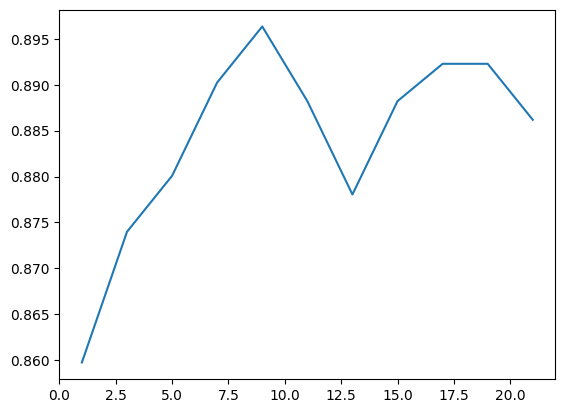

In [7]:
plt.plot(table['k'], table['accu'])
plt.show

In [8]:
table = table.sort_values(by=['accu'], ascending=False)
print(table)
# looks like 9 is the best k value

     k      accu
4    9  0.896341
8   17  0.892276
9   19  0.892276
3    7  0.890244
7   15  0.888211
5   11  0.888211
10  21  0.886179
2    5  0.880081
6   13  0.878049
1    3  0.873984
0    1  0.859756


In [9]:
random.seed(42)
np.random.seed(42)
class_knn = KNeighborsClassifier(n_neighbors=9)
class_knn.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=9)

### 3. Experiment with the threshold function, what happens at higher and lower thresholds. Document what you see in comments. 


In [10]:
test_probs = class_knn.predict_proba(X_test)
test_preds = class_knn.predict(X_test)

In [11]:
Test.head()

,control,cohort_size,awards_per_value,state_sector_ct,ft_pct,hbcu_N,hbcu_Y
147,Private,-0.621889,0.973413,-1.071605,1.141158,True,False
1217,Private,-0.350975,0.131490,-1.036877,0.795851,True,False
1251,Private,-0.269923,-0.186798,0.143881,0.647289,True,False
71,Private,-0.689617,-1.049255,-0.411770,-0.533180,True,False
1657,Public,-0.323217,-0.443481,-0.550683,-1.737740,True,False


In [12]:
test_probabilities = pd.DataFrame(test_probs, columns = ['priv_prob', 'pub_prob'])
test_probabilities.head()

,priv_prob,pub_prob
0,1.000000,0.000000
1,0.888889,0.111111
2,0.666667,0.333333
3,0.222222,0.777778
4,0.000000,1.000000


In [13]:
final_model = pd.DataFrame({'actual_class': Y_test.tolist(),
                           'pred_class': test_preds.tolist(),
                           'pred_prob': test_probabilities['pub_prob']})

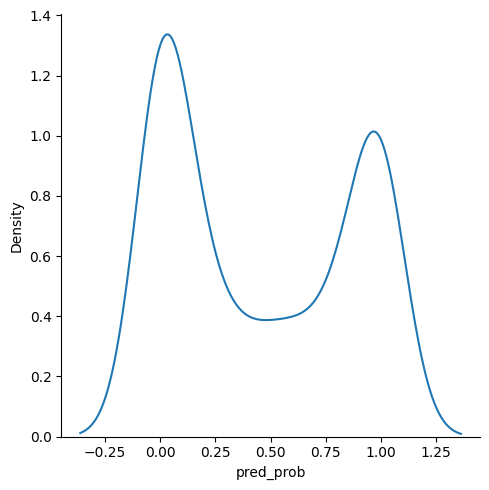

In [14]:
final_model.actual_class = final_model.actual_class.astype('category')
final_model.pred_class = final_model.pred_class.astype('category')
sns.displot(final_model, x="pred_prob", kind="kde")

In [15]:
print(final_model.pred_prob.value_counts())

pred_prob
0.000000    157
1.000000    120
0.111111     49
0.888889     34
0.222222     26
0.777778     25
0.555556     25
0.333333     21
0.444444     18
0.666667     18
Name: count, dtype: int64


In [16]:
def adjust_thres(x, y, z):
    """
    x=pred_probabilities
    y=threshold
    z=tune_outcome
    """
    thres = pd.DataFrame({'new_preds': ['Public' if i > y else 'Private' for i in x]})
    thres.new_preds = thres.new_preds.astype('category')
    con_mat = confusion_matrix(z, thres)  
    return con_mat


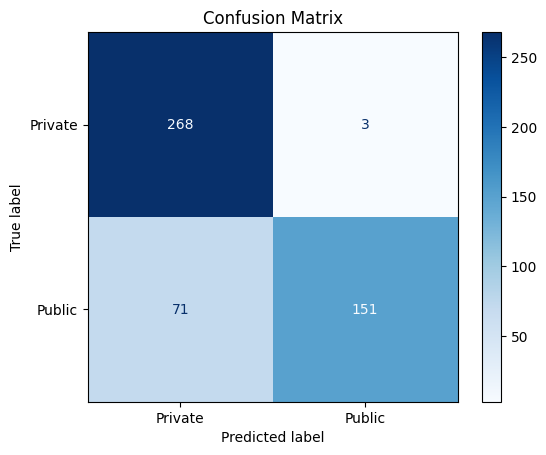

In [17]:
#upping the threshold to 0.8
cm = adjust_thres(final_model.pred_prob, .80, final_model.actual_class) 

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Private', 'Public'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [18]:
sensitivity = 151/222   # = TP/(TP+FN)
specificity = 268/271   # = TN/(TN+FP)
print(sensitivity, specificity)

#this model is really good at predicting private status correctly, 
#but the sensitivity to public school status isn't great

0.6801801801801802 0.988929889298893


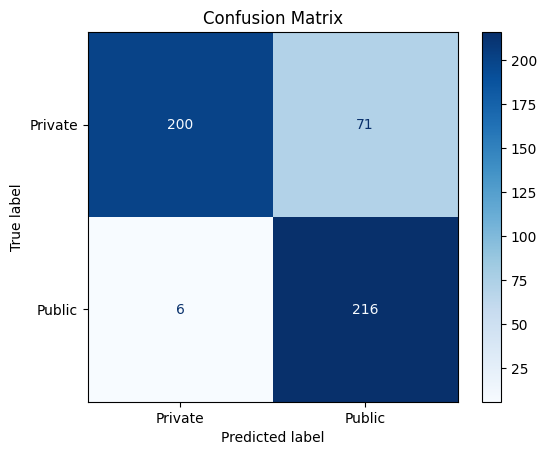

In [19]:
#lowering the threshold to 0.2
cm = adjust_thres(final_model.pred_prob, .20, final_model.actual_class) 

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Private', 'Public'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [20]:
sensitivity = 216/222   # = TP/(TP+FN)
specificity = 200/271   # = TN/(TN+FP)
print(sensitivity, specificity)

# high specificity but relatively low sensitivity- but overall better than the low threshold

0.972972972972973 0.7380073800738007


In [29]:
adjust_thres(final_model.pred_prob, .3 , final_model.actual_class)

array([[219,  52],
       [ 13, 209]])

In [ ]:
adjust_thres(final_model.pred_prob, .7 , final_model.actual_class)
#overall it seems like thresholds higher than 0.5 perform better

array([[264,   7],
       [ 50, 172]])

### 4. Evaluate the results using the confusion matrix (at the default threshold). Then talk through your question, summarize what concerns or positive elements do you have about the model? 

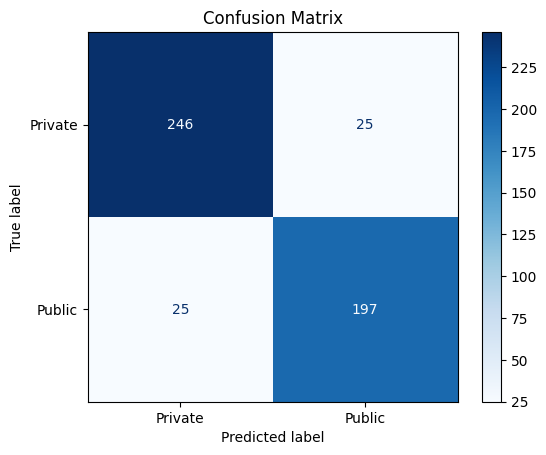

In [23]:
#with my original model, threshold=0.5
cm = confusion_matrix(final_model.actual_class, final_model.pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Private', 'Public'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [24]:
sensitivity = 197/222  # = TP/(TP+FN)
specificity = 246/271   # = TN/(TN+FP)
print(sensitivity, specificity)

# high specificy and sensitivity, a strong model with the threshold of 0.5

0.8873873873873874 0.9077490774907749


To answer my question, I would say that we can indeed predict the type of college from other information in our dataset. My model with 9 neighbors considered and a threshold from 0.5 has both high specificity and sensitivity. This model is slightly better at identifying private schools than it is public schools, so that would be a concern depending on the context the model was being used in. That said, both the specificity and sensitivity are higher than the public and private prevalence- so this model is definitely useful!